In [1]:
import torch
import torchvision
import os
from os.path import join as j_
from PIL import Image
import pandas as pd
import numpy as np

# loading all packages here to start
from uni import get_encoder
from uni.downstream.extract_patch_features import extract_patch_features_from_dataloader
from uni.downstream.eval_patch_features.linear_probe import eval_linear_probe
from uni.downstream.eval_patch_features.fewshot import eval_knn, eval_fewshot
from uni.downstream.eval_patch_features.protonet import ProtoNet, prototype_topk_vote
from uni.downstream.eval_patch_features.metrics import get_eval_metrics, print_metrics
from uni.downstream.utils import concat_images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Downloading UNI 2 weights + Creating Model

The function `get_encoder` performs the commands above, downloading in the checkpoint in the `./assets/ckpts/` relative path of this GitHub repository.

In [2]:
from uni import get_encoder
model, transform = get_encoder(enc_name='uni', device=device)

### Download CRC-100K (No Norm)

You can download the CRC-100K ROI dataset at the following link: https://zenodo.org/records/1214456, which is a 9-class colorectal tissue classification task.
- Train (100K images, 11.7 GB): https://zenodo.org/records/1214456/files/NCT-CRC-HE-100K-NONORM.zip?download=1
- Test (7.180K images, 800.3 MB): https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip?download=1

Once you download these *.zip files, you can unzup them in your local directory (this example puts it in the `UNI/assets/data/CRC100K` relative path of the GitHub repository). The organization of these folders follows the the `torchvision.datasets.ImageFolder` structure, where the subfolders are labeled by the object class, and the images in each folder are of the same class.


In [9]:
# 查看模型配置
print("=" * 50)
print("UNI 模型配置:")
print("=" * 50)
print(f"模型类型: {type(model).__name__}")
print(f"特征维度: {model.embed_dim if hasattr(model, 'embed_dim') else 'N/A'}")
print(f"Patch size: {model.patch_embed.patch_size if hasattr(model, 'patch_embed') else 'N/A'}")
print(f"图像尺寸: {model.patch_embed.img_size if hasattr(model, 'patch_embed') else 'N/A'}")
print(f"Transformer 层数: {len(model.blocks) if hasattr(model, 'blocks') else 'N/A'}")
print(f"注意力头数: {model.blocks[0].attn.num_heads if hasattr(model, 'blocks') else 'N/A'}")

print("\n" + "=" * 50)
print("模型参数统计:")
print("=" * 50)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数: {trainable_params:,}")
print(f"冻结参数: {total_params - trainable_params:,}")

print("=" * 50)
print("UNI 模型层级结构:")
print("=" * 50)
for name, module in model.named_children():
    print(f"\n{name}: {type(module).__name__}")
    if name == 'blocks':
        print(f"  └─ Transformer Blocks 数量: {len(module)}")
        print(f"     示例 Block 0 结构:")
        for sub_name, sub_module in list(module[0].named_children()):
            print(f"       └─ {sub_name}: {type(sub_module).__name__}")

UNI 模型配置:
模型类型: VisionTransformer
特征维度: 1024
Patch size: (16, 16)
图像尺寸: (224, 224)
Transformer 层数: 24
注意力头数: 16

模型参数统计:
总参数量: 303,350,784
可训练参数: 303,350,784
冻结参数: 0
UNI 模型层级结构:

patch_embed: PatchEmbed

pos_drop: Dropout

patch_drop: Identity

norm_pre: Identity

blocks: Sequential
  └─ Transformer Blocks 数量: 24
     示例 Block 0 结构:
       └─ norm1: LayerNorm
       └─ attn: Attention
       └─ ls1: LayerScale
       └─ drop_path1: Identity
       └─ norm2: LayerNorm
       └─ mlp: Mlp
       └─ ls2: LayerScale
       └─ drop_path2: Identity

norm: LayerNorm

fc_norm: Identity

head_drop: Dropout

head: Identity


In [3]:
dataroot = '../assets/data/CRC100K/'
assert os.path.isdir('../assets/data/CRC100K/NCT-CRC-HE-100K-NONORM')
assert os.path.isdir('../assets/data/CRC100K/CRC-VAL-HE-7K')

### ROI Feature Extraction

In [4]:
import time
from uni.downstream.extract_patch_features import extract_patch_features_from_dataloader

# get path to example data
start = time.time()
dataroot = '../assets/data/CRC100K/'

# create some image folder datasets for train/test and their data laoders
train_dataset = torchvision.datasets.ImageFolder(j_(dataroot, 'NCT-CRC-HE-100K-NONORM'), transform=transform)
test_dataset = torchvision.datasets.ImageFolder(j_(dataroot, 'CRC-VAL-HE-7K'), transform=transform)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=False, num_workers=16)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=16)

# extract patch features from the train and test datasets (returns dictionary of embeddings and labels)
train_features = extract_patch_features_from_dataloader(model, train_dataloader)
test_features = extract_patch_features_from_dataloader(model, test_dataloader)

# convert these to torch
train_feats = torch.Tensor(train_features['embeddings'])
train_labels = torch.Tensor(train_features['labels']).type(torch.long)
test_feats = torch.Tensor(test_features['embeddings'])
test_labels = torch.Tensor(test_features['labels']).type(torch.long)
elapsed = time.time() - start
print(f'Took {elapsed:.03f} seconds')

  0%|          | 1/391 [00:12<1:22:34, 12.70s/it]


KeyboardInterrupt: 

### ROI Linear Probe Evaluation.

In [ ]:
from uni.downstream.eval_patch_features.linear_probe import eval_linear_probe

linprobe_eval_metrics, linprobe_dump = eval_linear_probe(
    train_feats = train_feats,
    train_labels = train_labels,
    valid_feats = None ,
    valid_labels = None,
    test_feats = test_feats,
    test_labels = test_labels,
    max_iter = 1000,
    verbose= True,
)

print_metrics(linprobe_eval_metrics)

Linear Probe Evaluation: Train shape torch.Size([100000, 1024])
Linear Probe Evaluation: Test shape torch.Size([7180, 1024])
Linear Probe Evaluation (Train Time): Best cost = 92.160
Linear Probe Evaluation (Train Time): Using only train set for evaluation. Train Shape:  torch.Size([100000, 1024])
(Before Training) Loss: 2.197
(After Training) Loss: 0.023
Linear Probe Evaluation (Test Time): Test Shape torch.Size([7180, 1024])
Linear Probe Evaluation: Time taken 3.11
Test lin_acc: 0.869
Test lin_bacc: 0.874
Test lin_kappa: 0.910
Test lin_weighted_f1: 0.876
Test lin_auroc: 0.990


### ROI KNN and ProtoNet evaluation.

In [ ]:
from uni.downstream.eval_patch_features.fewshot import eval_knn

knn_eval_metrics, knn_dump, proto_eval_metrics, proto_dump = eval_knn(
    train_feats = train_feats,
    train_labels = train_labels,
    test_feats = test_feats,
    test_labels = test_labels,
    center_feats = True,
    normalize_feats = True,
    n_neighbors = 20
)

print_metrics(knn_eval_metrics)
print_metrics(proto_eval_metrics)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\ziyao\.conda\envs\UNI\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\ziyao\.conda\envs\UNI\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\ziyao\.conda\envs\UNI\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\ziyao\.conda\envs\UNI\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\ziyao\.conda\envs\UNI\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


Test knn20_acc: 0.944
Test knn20_bacc: 0.924
Test knn20_kappa: 0.974
Test knn20_weighted_f1: 0.945
Test proto_acc: 0.908
Test proto_bacc: 0.899
Test proto_kappa: 0.917
Test proto_weighted_f1: 0.912


### ROI Few-Shot Evaluation (based on ProtoNet)

In [ ]:
from uni.downstream.eval_patch_features.fewshot import eval_fewshot

fewshot_episodes, fewshot_dump = eval_fewshot(
    train_feats = train_feats,
    train_labels = train_labels,
    test_feats = test_feats,
    test_labels = test_labels,
    n_iter = 100, # draw 100 few-shot episodes
    n_way = 9, # use all class examples
    n_shot = 16, # 16 examples per class (as we don't have that many)
    n_query = test_feats.shape[0], # evaluate on all test samples
    center_feats = True,
    normalize_feats = True,
    average_feats = True,
)

# how well we did picking 4 random examples per class
display(fewshot_episodes)

# summary
display(fewshot_dump)

100%|██████████| 100/100 [00:04<00:00, 23.05it/s]


,Kw16s_acc,Kw16s_bacc,Kw16s_kappa,Kw16s_weighted_f1
0,0.853064,0.853436,0.835124,0.863907
1,0.902228,0.877038,0.946633,0.901227
2,0.909471,0.901557,0.946207,0.912180
3,0.917688,0.896924,0.918869,0.923441
4,0.900557,0.892736,0.892815,0.908067
...,...,...,...,...
95,0.878273,0.867718,0.894168,0.878691
96,0.865181,0.862397,0.928400,0.873746
97,0.855710,0.856896,0.858215,0.862928
98,0.880223,0.877810,0.852727,0.892197


{'Kw16s_acc_avg': 0.8786699164345404,
 'Kw16s_bacc_avg': 0.8707624812272116,
 'Kw16s_kappa_avg': 0.8872650529608543,
 'Kw16s_weighted_f1_avg': 0.8844569702208593,
 'Kw16s_acc_std': 0.040336620024602206,
 'Kw16s_bacc_std': 0.03380573105895631,
 'Kw16s_kappa_std': 0.06402780757186617,
 'Kw16s_weighted_f1_std': 0.038078971274827726}

### A Closer Look at ProtoNet

You can use ProtoNet in a sklearn-like API as well for fitting and predicting models.

In [ ]:
from uni.downstream.eval_patch_features.protonet import ProtoNet

# fitting the model
proto_clf = ProtoNet(metric='L2', center_feats=True, normalize_feats=True)
proto_clf.fit(train_feats, train_labels)
print('What our prototypes look like', proto_clf.prototype_embeddings.shape)

# evaluating the model
test_pred = proto_clf.predict(test_feats)
get_eval_metrics(test_labels, test_pred, get_report=False)

Num features averaged per class prototype:
	Class 0: 10407
	Class 1: 10566
	Class 2: 11512
	Class 3: 11557
	Class 4: 8896
	Class 5: 13536
	Class 6: 8763
	Class 7: 10446
	Class 8: 14317
Applying centering...
Applying normalization...
What our prototypes look like torch.Size([9, 1024])


{'acc': 0.9077994428969359,
 'bacc': 0.898610901678711,
 'kappa': 0.9170858123751495,
 'weighted_f1': 0.9121016982605245}

Using `proto_clf._get_topk_queries_inds`, we use the test samples as the query set, and get the top-k queries to each prototype, effectively doing ROI retrieval.

label2idx correspondenes {'ADI': 0, 'BACK': 1, 'DEB': 2, 'LYM': 3, 'MUC': 4, 'MUS': 5, 'NORM': 6, 'STR': 7, 'TUM': 8}
Top-k ADIPOSE-like test samples to ADIPOSE prototype


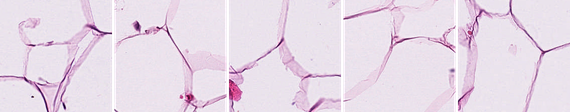

Top-k LYMPHOCYTE-like test samples to LYMPHOCYTE prototype


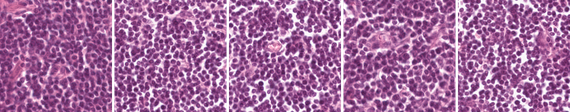

Top-k MUCOSA-like test samples to MUCOSA prototype


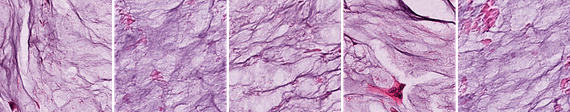

Top-k MUSCLE-like test samples to MUSCLE prototype


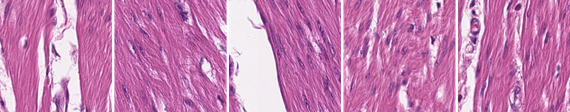

Top-k NORMAL-like test samples to NORMAL prototype


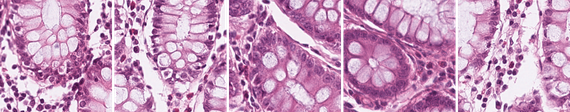

Top-k STROMA-like test samples to STROMA prototype


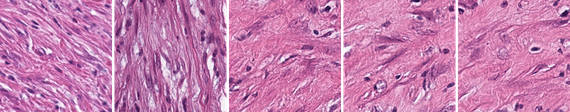

Top-k TUMOR-like test samples to TUMOR prototype


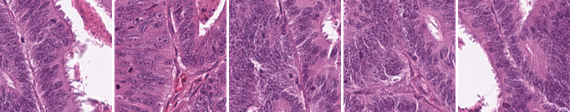

In [ ]:
dist, topk_inds = proto_clf._get_topk_queries_inds(test_feats, topk=5)
print('label2idx correspondenes', test_dataset.class_to_idx)
test_imgs_df = pd.DataFrame(test_dataset.imgs, columns=['path', 'label'])

print('Top-k ADIPOSE-like test samples to ADIPOSE prototype')
adi_topk_inds = topk_inds[0]
adi_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][adi_topk_inds]], scale=0.5, gap=5)
display(adi_topk_imgs)

print('Top-k LYMPHOCYTE-like test samples to LYMPHOCYTE prototype')
lym_topk_inds = topk_inds[3]
lym_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][lym_topk_inds]], scale=0.5, gap=5)
display(lym_topk_imgs)

print('Top-k MUCOSA-like test samples to MUCOSA prototype')
muc_topk_inds = topk_inds[4]
muc_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][muc_topk_inds]], scale=0.5, gap=5)
display(muc_topk_imgs)

print('Top-k MUSCLE-like test samples to MUSCLE prototype')
mus_topk_inds = topk_inds[5]
mus_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][mus_topk_inds]], scale=0.5, gap=5)
display(mus_topk_imgs)

print('Top-k NORMAL-like test samples to NORMAL prototype')
norm_topk_inds = topk_inds[6]
norm_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][norm_topk_inds]], scale=0.5, gap=5)
display(norm_topk_imgs)

print('Top-k STROMA-like test samples to STROMA prototype')
str_topk_inds = topk_inds[7]
str_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][str_topk_inds]], scale=0.5, gap=5)
display(str_topk_imgs)

print('Top-k TUMOR-like test samples to TUMOR prototype')
tum_topk_inds = topk_inds[8]
tum_topk_imgs = concat_images([Image.open(img_fpath) for img_fpath in test_imgs_df['path'][tum_topk_inds]], scale=0.5, gap=5)
display(tum_topk_imgs)


Using `proto_clf._get_topk_prototypes_inds`, we can instead use the prototypes as the query set, and get the top-k queries to each test sample. With k set to # of prototypes / labels, we are essentially doing ROI classification (assigning label of the nearest prototype to the test sample).

In [ ]:
dist, topk_inds = proto_clf._get_topk_prototypes_inds(test_feats, topk=9)
print("The top-9 closest prototypes to each test sample, with closer prototypes first (left hand side)")
display(topk_inds)

pred_test = topk_inds[:, 0]
get_eval_metrics(test_labels, test_pred, get_report=False)

The top-9 closest prototypes to each test sample, with closer prototypes first (left hand side)


array([[0, 7, 5, ..., 6, 3, 1],
       [0, 5, 7, ..., 4, 1, 3],
       [0, 5, 7, ..., 6, 3, 1],
       ...,
       [8, 5, 7, ..., 0, 4, 1],
       [6, 8, 5, ..., 4, 0, 1],
       [8, 2, 7, ..., 3, 0, 1]], dtype=int64)

{'acc': 0.9077994428969359,
 'bacc': 0.898610901678711,
 'kappa': 0.9170858123751495,
 'weighted_f1': 0.9121016982605245}